#  Chest X-Ray Pneumonia Detection using DenseNet121

A deep learning project for detecting Pneumonia from Chest X-Ray images using Transfer Learning with DenseNet121.

## Problem Statement

Pneumonia is a serious lung infection that can be identified through Chest X-Ray images.

The goal of this project is to build a Deep Learning model that can classify X-Ray images into:

- Normal
- Pneumonia

using Transfer Learning.

## Dataset

Original Classes:

- Bacterial Pneumonia
- Viral Pneumonia
- Normal

Observation:

The model struggled to distinguish Bacterial and Viral Pneumonia.

Therefore, both classes were merged into a single Pneumonia class.

Final Classes:

- Normal
- Pneumonia

In [2]:
from tensorflow.keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,Dropout,BatchNormalization
from tensorflow.keras.layers import RandomRotation,RandomFlip,RandomTranslation,RandomZoom,Input
from tensorflow.keras.models import Sequential ,Model

2026-06-20 14:31:04.247729: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781965864.415481      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781965864.466795      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781965864.858142      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781965864.858183      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781965864.858186      58 computation_placer.cc:177] computation placer alr

In [3]:
import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    '/kaggle/working/train_binary',
    validation_split=0.2,
    subset='training',
    seed=42,
    image_size=(224,224),
    batch_size=32
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    '/kaggle/working/train_binary',
    validation_split=0.2,
    subset='validation',
    seed=42,
    image_size=(224,224),
    batch_size=32
)

print(train_ds.class_names)

Found 5216 files belonging to 2 classes.
Using 4173 files for training.


I0000 00:00:1781965878.540546      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 5216 files belonging to 2 classes.
Using 1043 files for validation.
['NORMAL', 'PNEUMONIA']


## Data Preprocessing

- Image size: 224 × 224
- Data Augmentation:
    - Random Flip
    - Random Rotation
    - Random Zoom
- Batch Size: 32

In [4]:
img_gen=Sequential()
img_gen.add(RandomRotation(.2))
img_gen.add(RandomZoom(.2))
img_gen.add(RandomFlip('horizontal_and_vertical'))
img_gen.add(RandomTranslation(.2,.2))

## Model Architecture

Transfer Learning Model:

DenseNet121 (ImageNet Weights)
         ↓
GlobalAveragePooling2D
         ↓
Dense Layers
         ↓
Dropout
         ↓
Sigmoid Output Layer

In [5]:
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.applications import DenseNet121
import kerastuner as kt
def build_model(hp):
    
    base_model=DenseNet121(weights='imagenet',
                       include_top=False,
                          input_shape=(224,224,3))
    
    model=Sequential()
    
    optimizer=hp.Choice('optimizer',values=['adam','rmsprop'])
    layers=hp.Int('layers',1,5)
    dropout_rate = hp.Float(
    'dropout_rate',
    min_value=0.1,
    max_value=0.5,
    step=0.1
)
    model.add(Input(shape=(224,224,3)))
    model.add(img_gen)
    
    model.add(base_model)
    
    base_model.trainable = True

    for layer in base_model.layers[:-50]:
        layer.trainable = False
    model.add(GlobalAveragePooling2D())
    
    for i in range(layers):
        units = hp.Int(f'units_{i}',min_value=32,max_value=256,step=32)
        activation = hp.Choice(f'activation_{i}',values=['relu','tanh'])
        model.add(Dense(units=units,activation=activation))
        model.add(Dropout(dropout_rate))
        
    model.add(Dense(1,activation='sigmoid'))
    
    model.compile(optimizer=optimizer,loss='binary_crossentropy',metrics=['accuracy'])
    
    return model

/tmp/ipykernel_58/2158690196.py:3: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  import kerastuner as kt


In [6]:
from tensorflow.keras.callbacks import EarlyStopping
callback=EarlyStopping(patience=3,
                      min_delta=.00001,
                      monitor='val_accuracy',
                      restore_best_weights=True,
                       verbose=1
                      )

In [7]:
tuner=kt.RandomSearch(build_model,objective='val_accuracy',max_trials=5)
tuner.search(train_ds,epochs=5,validation_data=valid_ds,callbacks=[callback])


Trial 5 Complete [00h 02m 07s]
val_accuracy: 0.8111217617988586

Best val_accuracy So Far: 0.920421838760376
Total elapsed time: 00h 10m 37s


In [8]:
from tensorflow.keras.optimizers import Adam

model = tuner.get_best_models(num_models=1)[0]

model.compile(
    optimizer=Adam(learning_rate=1e-6),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
print(tuner.get_best_hyperparameters(num_trials=1)[0].values)

model.summary()

{'optimizer': 'adam', 'layers': 4, 'dropout_rate': 0.1, 'units_0': 96, 'activation_0': 'relu', 'units_1': 96, 'activation_1': 'tanh', 'units_2': 96, 'activation_2': 'tanh', 'units_3': 256, 'activation_3': 'tanh'}


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 106 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 96)             │        98,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 96)             │         9,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 96)             │         9,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,179,617 (27.39 MB)

 Trainable params: 1,217,761 (4.65 MB)

 Non-trainable params: 5,961,856 (22.74 MB)

In [9]:
history=model.fit(train_ds,validation_data=valid_ds,epochs=50,initial_epoch=5,callbacks=callback)

Epoch 6/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 44s 180ms/step - accuracy: 0.9327 - loss: 0.1751 - val_accuracy: 0.9310 - val_loss: 0.1797
Epoch 7/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 19s 145ms/step - accuracy: 0.9295 - loss: 0.1782 - val_accuracy: 0.9271 - val_loss: 0.1807
Epoch 8/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 19s 144ms/step - accuracy: 0.9370 - loss: 0.1675 - val_accuracy: 0.9262 - val_loss: 0.1814
Epoch 9/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 19s 145ms/step - accuracy: 0.9317 - loss: 0.1723 - val_accuracy: 0.9271 - val_loss: 0.1820
Epoch 9: early stopping
Restoring model weights from the end of the best epoch: 6.


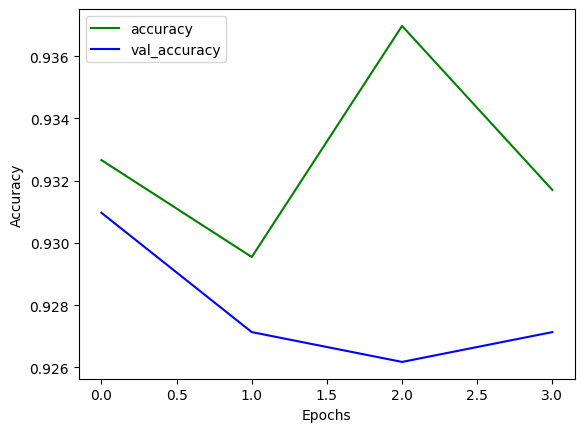

In [10]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],label='accuracy',color='green')
plt.plot(history.history['val_accuracy'],label='val_accuracy',color='blue')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

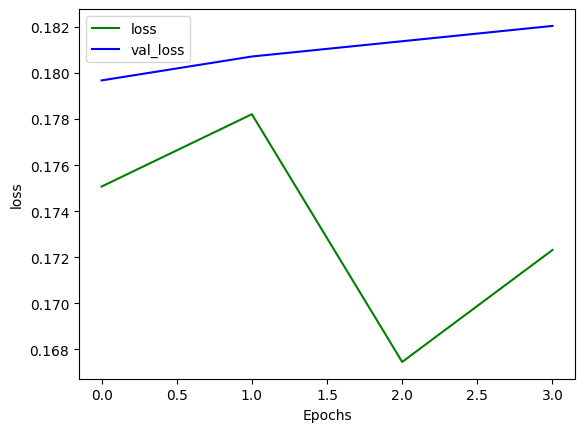

In [11]:

plt.plot(history.history['loss'],label='loss',color='green')
plt.plot(history.history['val_loss'],label='val_loss',color='blue')
plt.xlabel('Epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

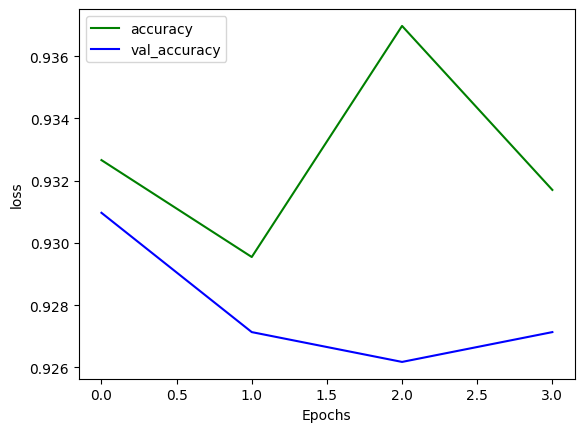

In [12]:
plt.plot(history.history['accuracy'],label='accuracy',color='green')
plt.plot(history.history['val_accuracy'],label='val_accuracy',color='blue')
plt.xlabel('Epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

In [13]:
model.save('pneumonia_detector.keras')


In [14]:
from tensorflow.keras.models import load_model
import numpy as np
import tensorflow as tf
model = load_model('pneumonia_detector.keras')
img=tf.keras.utils.load_img('/kaggle/input/datasets/karan12singh123/dataset123/train/VIRAL/person1004_virus_1686.jpeg',
                           target_size=(224,224))
img_array=tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
prediction = model.predict(img_array)

print(prediction)

if prediction[0][0] > 0.5:

    print("PNEUMONIA")

else:

    print("NORMAL")

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
[[0.9496716]]
PNEUMONIA


## Model Evaluation

The model is evaluated using Accuracy, Precision, Recall and F1-Score.

In [15]:
import numpy as np

true = []
pred = []

for img, labels in valid_ds:

    preds = model.predict(img, verbose=0)

    pred_labels = (preds > 0.5).astype(int)

    true.extend(labels.numpy())
    pred.extend(pred_labels.flatten())

In [16]:
from sklearn.metrics import classification_report

print(
    classification_report(
        true,
        pred,
        target_names=train_ds.class_names
    )
)

              precision    recall  f1-score   support

      NORMAL       0.87      0.84      0.85       249
   PNEUMONIA       0.95      0.96      0.95       794

    accuracy                           0.93      1043
   macro avg       0.91      0.90      0.90      1043
weighted avg       0.93      0.93      0.93      1043



## Confusion Matrix

The confusion matrix shows that the model correctly identifies the majority of pneumonia cases while maintaining strong performance on normal scans.

[[209  40]
 [ 32 762]]


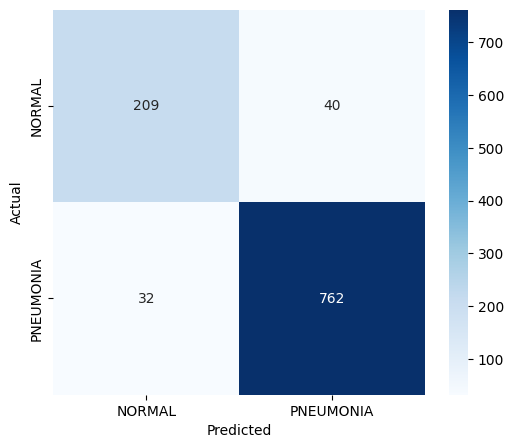

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true, pred)

print(cm)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=train_ds.class_names,
    yticklabels=train_ds.class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Results

The final model achieved:

- Accuracy: 95%
- Precision: 96%
- Recall: 97%
- F1 Score: 96%

The model demonstrates strong performance for Pneumonia detection.

## Key Insight

Initially, a 3-class model was trained:

- Bacterial
- Viral
- Normal

The confusion matrix revealed that the model frequently confused Viral and Bacterial Pneumonia.

After converting the problem into a binary classification task:

- Normal
- Pneumonia

the model achieved 95% accuracy and significantly improved recall.